## Project : Bank desertion rate.

Harold TAGNY NGNIPOUE <br>
Sandy Lunalor TEFOUEGOUM <br>
Alida Dovila Zogo

The goal of this project is to predict whether a customer will leave their bank in order to anticipate customer retention measures.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score,precision_score,recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier, StackingClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

### 1 - Descriptive Analysis

In [3]:
df = pd.read_csv("BankChurners.csv", sep = ",", usecols=list(range(0,21)))

In [4]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [5]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,2,4,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [7]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


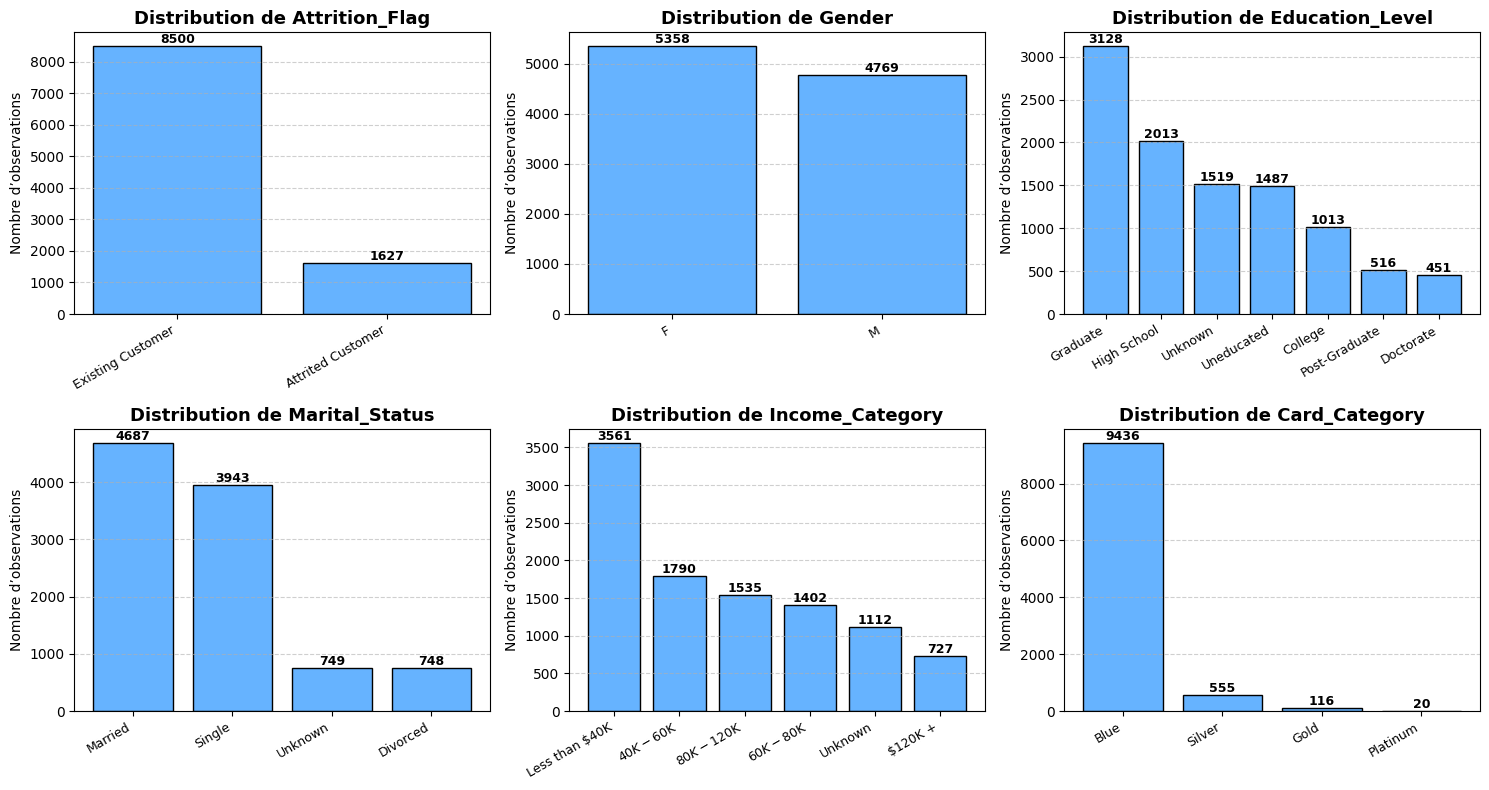

In [8]:
cols = ['Attrition_Flag', 'Gender', 'Education_Level',
        'Marital_Status', 'Income_Category', 'Card_Category']

plt.figure(figsize=(15, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)

    value_counts = df[col].value_counts()
    bars = plt.bar(value_counts.index, value_counts.values,
                   color='#66b3ff', edgecolor='black')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.title(f'Distribution de {col}', fontsize=13, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Nombre d’observations', fontsize=10)
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

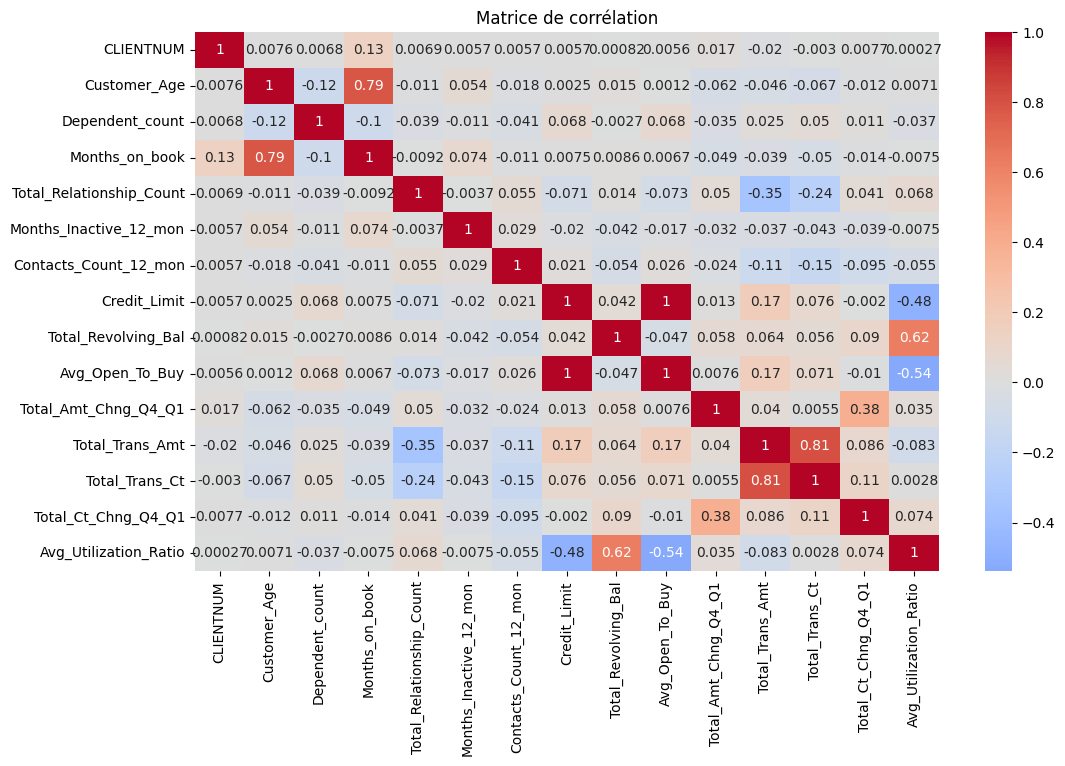

In [9]:
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.show()

#### Observations:

We have a total of 21 variables in our dataset and 10 127 observations.

We have 8 500 existing customers in the bank and 1 627 who have terminated their contracts. <br>
This represents a proportion of 83.93% of existing customers and 16.07% of customers who have terminated their contracts. We therefore have a bias in our database.
<br>

In terms of gender in the dataset, we have 53% women and 47% men.  
The distribution is more balanced than our variable of interest.

## 2 - Pre-Processing :

We start by removing the “CLIENTNUM” variable because this variable identifies the client, but we want a model that can be adapted to all clients, not just certain targeted clients.

In [10]:
df = df.drop(columns=['CLIENTNUM'])

We now check whether we have any missing variables in our dataset, which will allow us to determine what we can do next to replace them (median, mean, PCA, ...)

In [11]:
df.isna().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


Although we do not have any missing variables in our dataset, we have observed that the variables “Education_Level,” “Marital_Status,” and “Income_Category” have ‘Unknown’ values. Since this information is still useful and we want as much information as possible for our model to be successful, we will process the variables with “Unknown” values. We also categorize the variables “Gender” and “Marital_Status” in order to have an even distribution.

In [12]:
print("Observations with 'Uknown': {} sur {}".format((df[(df["Education_Level"] == "Unknown") |
   (df["Marital_Status"] == "Unknown") |
   (df["Income_Category"] == "Unknown")].shape[0]), df.shape[0]))

Observations with 'Uknown': 3046 sur 10127


We have 3 046 “Unknown” variables out of 10 127. Let's process them now so that we can use them in our model.

In [13]:
# Variables à encoder
ordinal_cols = ["Education_Level", "Income_Category", "Card_Category"]
onehot_cols = ["Gender", "Marital_Status"]

# Définition des ordres logiques pour les variables ordinales
education_order = ["Unknown", "Uneducated", "High School", "College", "Graduate", "Post-Graduate", "Doctorate"]
income_order = ["Unknown", "Less than $40K", "$40K - $60K", "$60K - $80K", "$80K - $120K", "$120K +"]
card_order = ["Blue", "Silver", "Gold", "Platinum"]

# Création d'une copie pour ne pas modifier df
df_enc = df.copy()

# Encodage ordinal (les catégories sont converties en valeurs entières selon l'ordre défini)
ord_encoder = OrdinalEncoder(categories=[education_order, income_order, card_order])
df_enc[ordinal_cols] = ord_encoder.fit_transform(df_enc[ordinal_cols])

# Encodage one-hot (les catégories deviennent des colonnes binaires)
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
onehot_encoded = pd.DataFrame(onehot_encoder.fit_transform(df_enc[onehot_cols]), columns=onehot_encoder.get_feature_names_out(onehot_cols), index=df_enc.index)


df_enc = pd.concat([df_enc.drop(columns=onehot_cols), onehot_encoded], axis=1)
df_enc.head()

,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,...,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_F,Gender_M,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown
0,Existing Customer,45,3,2.0,3.0,0.0,39,5,1,3,...,1144,42,1.625,0.061,0.0,1.0,0.0,1.0,0.0,0.0
1,Existing Customer,49,5,4.0,1.0,0.0,44,6,1,2,...,1291,33,3.714,0.105,1.0,0.0,0.0,0.0,1.0,0.0
2,Existing Customer,51,3,4.0,4.0,0.0,36,4,1,0,...,1887,20,2.333,0.000,0.0,1.0,0.0,1.0,0.0,0.0
3,Existing Customer,40,4,2.0,1.0,0.0,34,3,4,1,...,1171,20,2.333,0.760,1.0,0.0,0.0,0.0,0.0,1.0
4,Existing Customer,40,3,1.0,3.0,0.0,21,5,1,0,...,816,28,2.500,0.000,0.0,1.0,0.0,1.0,0.0,0.0


Having determined that we have no missing variables in our database, we can now move on to encoding our target variable.
In order to determine the classes of our target variable, we identify existing customers with a flag of 0 and customers who have terminated their contracts with a flag of 1, as we are primarily seeking to predict whether customers will leave the bank.

In [14]:
df_enc['Attrition_Flag'] = df_enc['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

In [15]:
df_enc.head()

,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,...,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_F,Gender_M,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown
0,0,45,3,2.0,3.0,0.0,39,5,1,3,...,1144,42,1.625,0.061,0.0,1.0,0.0,1.0,0.0,0.0
1,0,49,5,4.0,1.0,0.0,44,6,1,2,...,1291,33,3.714,0.105,1.0,0.0,0.0,0.0,1.0,0.0
2,0,51,3,4.0,4.0,0.0,36,4,1,0,...,1887,20,2.333,0.000,0.0,1.0,0.0,1.0,0.0,0.0
3,0,40,4,2.0,1.0,0.0,34,3,4,1,...,1171,20,2.333,0.760,1.0,0.0,0.0,0.0,0.0,1.0
4,0,40,3,1.0,3.0,0.0,21,5,1,0,...,816,28,2.500,0.000,0.0,1.0,0.0,1.0,0.0,0.0


In order to bring our variables to the same scale, we standardize them, i.e., we center and reduce them so that the mean of our data is equal to 0 and the variance is 1. We do this because without standardization, the model would give more weight to variables with higher values such as “Credit_Limit” or “Total_Trans_Amt.”

In [16]:
X = df_enc.drop(columns=['Attrition_Flag'])
y = df_enc['Attrition_Flag']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 3 - Formalization of the problem :

Formalization of the problem :

We aim to perform a binary classification task to determine whether a customer is likely to leave the bank. Our target variable Attrition_Flag distinguishes two customer types:

- Existing Customer → active clients
- Attrited Customer → churned clients

The objective of this study is to accurately predict customer attrition based on demographic and financial indicators in order to support strategic customer retention actions.

| N°   | Nom de la variable           | Description de la variable                                                                                                                              |
| ---- | ---------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1️  | **CLIENTNUM**                | Unique customer ID (number assigned by the bank).                                                                                            |
| 2  | **Attrition_Flag**           | Customer status: <br>• *Existing Customer* → current customer <br>• *Attrited Customer* → customer who has left the bank.                                  |
| 3  | **Customer_Age**             | Age of the client.                                                                                                                                           |
| 4  | **Gender**                   | Sex of the client : *M* (Men) ou *F* (Women).                                                                                                             |
| 5  | **Dependent_count**          | Number of dependents (children, unemployed spouse, etc.).                                                                                      |
| 6  | **Education_Level**          | Client education level: *Uneducated*, *High School*, *Graduate*, *Doctorate*, etc.                                                                |
| 7  | **Marital_Status**           | Client's marital status: *Single*, *Married*, *Divorced*, *Unknown*, etc.                                                                              |
| 8  | **Income_Category**          | Customer's annual income bracket: <br>• *Less than $40K* <br>• *$40K - $60K* <br>• *$60K - $80K* <br>• *$80K - $120K* <br>• *$120K+* <br>• *Unknown*. |
| 9  | **Card_Category**            | Type of credit card owned: *Blue*, *Silver*, *Gold*, *Platinum*.                                                                                 |
| 10   | **Months_on_book**           | Customer's length of time with the bank (in months).                                                                                                           |
| 11 | **Total_Relationship_Count** | Total number of products held by the customer (e.g., checking account, savings account, card, loan, etc.).                                                         |
| 12 | **Months_Inactive_12_mon**   | Number of months of inactivity over the last 12 months.                                                                                                    |
| 13 | **Contacts_Count_12_mon**    | Number of contacts (calls, emails, interactions) between the bank and the customer over the last 12 months.                                                 |
| 14 | **Credit_Limit**             | Authorized credit limit for the customer's card.                                                                                                      |
| 15 | **Total_Revolving_Bal**      | Solde revolving total (partie du crédit utilisée mais non remboursée).                                                                                   |
| 16 | **Avg_Open_To_Buy**          | Average amount available on the card (remaining credit = limit − balance used).                                                                    |
| 17 | **Total_Amt_Chng_Q4_Q1**     | Change in total transaction volume between the fourth and first quarters (Q4/Q1). <br>→ Measures growth or decline in financial activity.         |
| 18 | **Total_Trans_Amt**          | Total amount of transactions carried out over 12 months.                                                                                                    |
| 19 | **Total_Trans_Ct**           | Total number of transactions completed over 12 months.                                                                                                      |
| 20 | **Total_Ct_Chng_Q4_Q1**      | Change in the number of transactions between the fourth and first quarters (Q4/Q1).                                                                         |
| 21 | **Avg_Utilization_Ratio**    | Average credit utilization rate (ratio between balance and credit limit). <br>Example: 0.2 = 20% of credit used.                          |




### Implementation of the Logistics Model:

We applied a stratified train-test split in order to preserve the original churn proportion across both datasets. This prevents sampling bias — for instance, ensuring that all churners do not accidentally end up in either the training or the test set. A fixed random seed was used to ensure reproducibility of the results.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2472   79]
 [ 226  262]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2551
           1       0.77      0.54      0.63       488

    accuracy                           0.90      3039
   macro avg       0.84      0.75      0.79      3039
weighted avg       0.89      0.90      0.89      3039



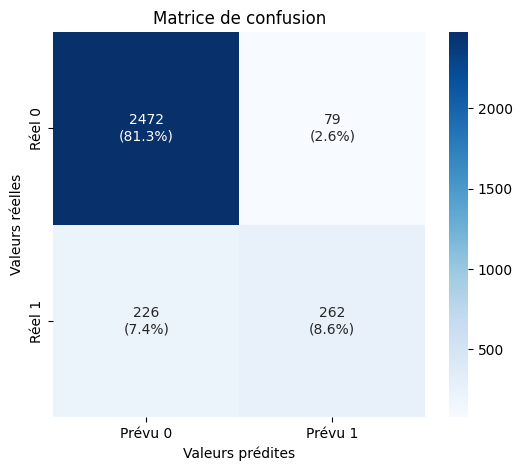

In [18]:
cm = confusion_matrix(y_test, y_pred)
cm_sum = np.sum(cm)
cm_perc = cm / cm_sum * 100

annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_perc[i, j]:.1f}%)"

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['Prévu 0', 'Prévu 1'],
            yticklabels=['Réel 0', 'Réel 1'])

plt.title('Matrice de confusion')
plt.xlabel('Valeurs prédites')
plt.ylabel('Valeurs réelles')
plt.show()

The model shows strong predictive capability for non-churn customers. However, churn detection remains more challenging, with a recall of approximately 77%, leading to an overall accuracy of 84.5%. In the following section, we explore methods to improve performance, particularly focusing on better detection of customers at churn risk.

## Model Comparison

### Grid Search

In [19]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 15],
    'min_samples_split': [3,4,5],
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}


Base on our grid_search, we can determine that our tree has no maximum depth, which allows the model to learn more complex patterns.
We also observe that a node must have at least 5 samples to be split, which helps avoid overfitting.
The forest contains 150 trees, which is a good compromise between performance and computation time.

Based on our results, we can say that we have found a good compromise between bias and variance.

### 1 - Random Forest

In [20]:
best_rf = RandomForestClassifier(max_depth=None, min_samples_split=5, n_estimators=150, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

print(f"Accuracy (Random Forest): {round(accuracy_score(y_test, y_pred_rf)*100,4)}%")
print(classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 95.6565%
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      2551
           1       0.92      0.80      0.85       488

    accuracy                           0.96      3039
   macro avg       0.94      0.89      0.91      3039
weighted avg       0.96      0.96      0.96      3039



The model correctly predicts approximately 95,66% of our test database.<br>
Class 0 is slightly better recognized than class 1.<br>
For class 0, almost all 0s are detected.<br>
For class 1, approximately 20% of true 1s are missed, but 80% are still detected, so there are few false positives.<br>
Overall, the model performs well.

/tmp/ipython-input-1659177508.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_rf[indices][:15], y=features[indices][:15], palette='crest')


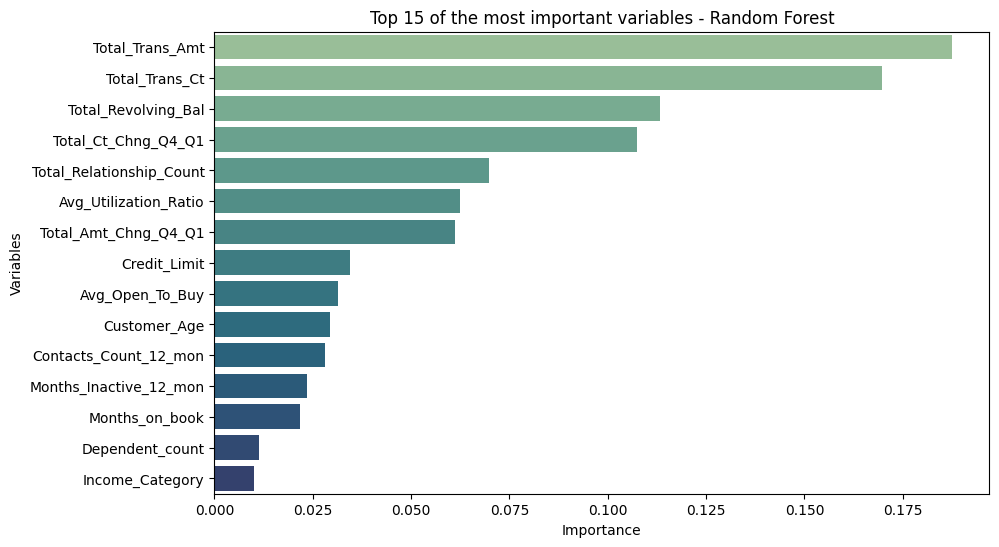

In [21]:
importances_rf = best_rf.feature_importances_
indices = np.argsort(importances_rf)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances_rf[indices][:15], y=features[indices][:15], palette='crest')
plt.title("Top 15 of the most important variables - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

The decision-making process of our Random Forest model is mainly determined by the following variables (for example the 5 firsts):

- The total transaction amount (Total_Trans_Amt) appears as the strongest predictor of churn. A decline in transaction volume or spending level is indicative of disengagement and may signal that a customer is preparing to leave the bank. <br>

- Total_Trans_Ct represents the number of transactions. The lower the number of transactions, the more likely the customer is to terminate their contract.

- Total_Revolving_Bal, which represents the account balance. A customer with a low or zero balance may be more likely to terminate their contract because they are less committed.

- Total_Ct_Chng_Q4_Q1, which determines the number of transactions between the first and fourth quarters. With a decreasing number of transactions, we can estimate that the commitment to the account is weaker, meaning that the customer is more likely to terminate their contract.

- Total_Relationship_Count represents the number of products held by the customer. The more products a customer has (premium card, insurance, accounts, loans, etc.), the less likely they are to leave.

### 2 - Bagging

In [22]:
bagging = BaggingClassifier( estimator=DecisionTreeClassifier(), n_estimators=150, random_state=42)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

print(f"Accuracy (Bagging): {round(accuracy_score(y_test, y_pred_bag) * 100,4)}%")


Accuracy (Bagging): 95.7223%


Bagging correctly predicts 95.7223% of the classification of our data.

### 3 - Voting

In [23]:
log_reg = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
rf = best_rf

voting = VotingClassifier(estimators=[('lr', log_reg), ('svm', svm), ('rf', rf)], voting='soft')

voting.fit(X_train, y_train)
y_pred_vote = voting.predict(X_test)

print(f"Accuracy (Voting):, {round(accuracy_score(y_test, y_pred_vote)*100,4)}%")

Accuracy (Voting):, 92.6621%


Voting correctly predicts 92.695% of the classification of our data.

### 4 - Stacking

In [24]:
estimators = [ ('rf', rf), ('svm', svm)]

stacking = StackingClassifier( estimators=estimators, final_estimator=LogisticRegression(), passthrough=True)
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)

print(f"Accuracy (Stacking):, {round(accuracy_score(y_test, y_pred_stack)*100,4)}%")

Accuracy (Stacking):, 96.1171%


Stacking correctly predicts 96.1171% of the classification of our data.

In [25]:
models = {
    "Random Forest": y_pred_rf,
    "Bagging": y_pred_bag,
    "Voting": y_pred_vote,
    "Stacking": y_pred_stack
}

for name, preds in models.items():
    print(f"\n===== {name} =====")
    print(f"Accuracy:  {round(accuracy_score(y_test, preds)*100, 4)}%")
    print(f"Precision: {round(precision_score(y_test, preds, average='weighted'), 4)}")
    print(f"Recall:    {round(recall_score(y_test, preds, average='weighted'), 4)}")
    print(f"F1-score:  {round(f1_score(y_test, preds, average='weighted'), 4)}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, preds))


===== Random Forest =====
Accuracy:  95.6565%
Precision: 0.9557
Recall:    0.9566
F1-score:  0.9553
Confusion matrix:
[[2518   33]
 [  99  389]]

===== Bagging =====
Accuracy:  95.7223%
Precision: 0.9564
Recall:    0.9572
F1-score:  0.9566
Confusion matrix:
[[2502   49]
 [  81  407]]

===== Voting =====
Accuracy:  92.6621%
Precision: 0.9237
Recall:    0.9266
F1-score:  0.9223
Confusion matrix:
[[2500   51]
 [ 172  316]]

===== Stacking =====
Accuracy:  96.1171%
Precision: 0.9605
Recall:    0.9612
F1-score:  0.9607
Confusion matrix:
[[2506   45]
 [  73  415]]


### Models comparison

/tmp/ipython-input-696815325.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=scores, palette='viridis')


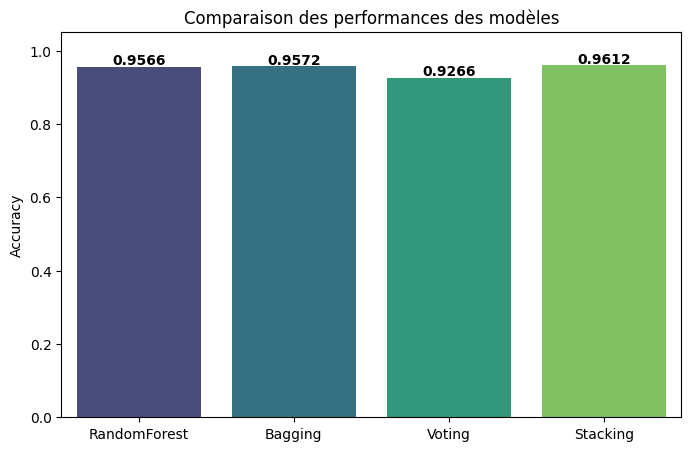

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

models = ['RandomForest', 'Bagging', 'Voting', 'Stacking']
scores = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_bag),
    accuracy_score(y_test, y_pred_vote),
    accuracy_score(y_test, y_pred_stack)
]

plt.figure(figsize=(8,5))
ax = sns.barplot(x=models, y=scores, palette='viridis')

plt.title("Comparaison des performances des modèles")
plt.ylabel("Accuracy")

for i, v in enumerate(scores):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.ylim(0, 1.05)
plt.show()

Comparing our four tested models, we observe that the most effective model is stacking, with 96.1% accuracy. For the other models, which also perform well, we observe that the accuracy is not very different. The second most effective model is Bagging. However, stacking takes more time and requires a large volume of data, whereas Random Forest can perform with less data and more quickly.

#### Roc Curve

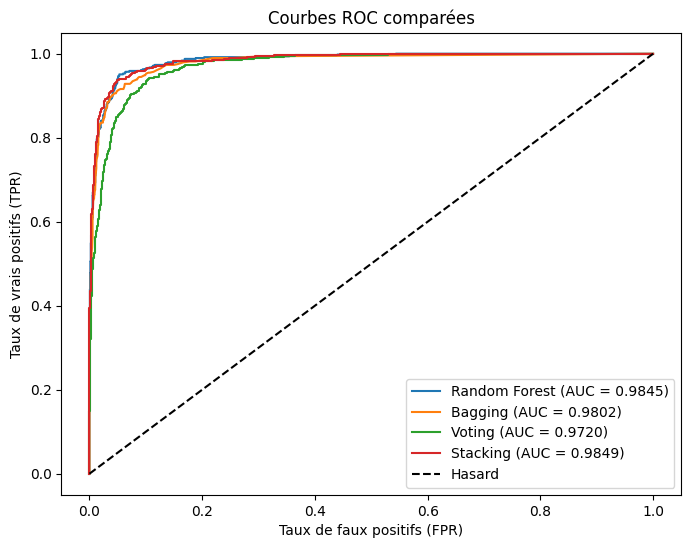

In [27]:
plt.figure(figsize=(8,6))

models_pred_prob = {
    'Random Forest': best_rf.predict_proba(X_test)[:,1], 'Bagging': bagging.predict_proba(X_test)[:,1],
    'Voting': voting.predict_proba(X_test)[:,1], 'Stacking': stacking.predict_proba(X_test)[:,1]}

for name, y_prob in models_pred_prob.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0,1], [0,1], 'k--', label='Hasard')
plt.title("Courbes ROC comparées")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend()
plt.show()

The ROC curve shows us the ability to distinguish between true and false positives. The diagonal line represents chance in a random classification. According to the AUC, stacking has the best performance (0.985), but the random forest model is not far behind (RF => 0.9845).
The Voting curve is slightly lower, which also corresponds to its lower AUC.

#### Recall curve

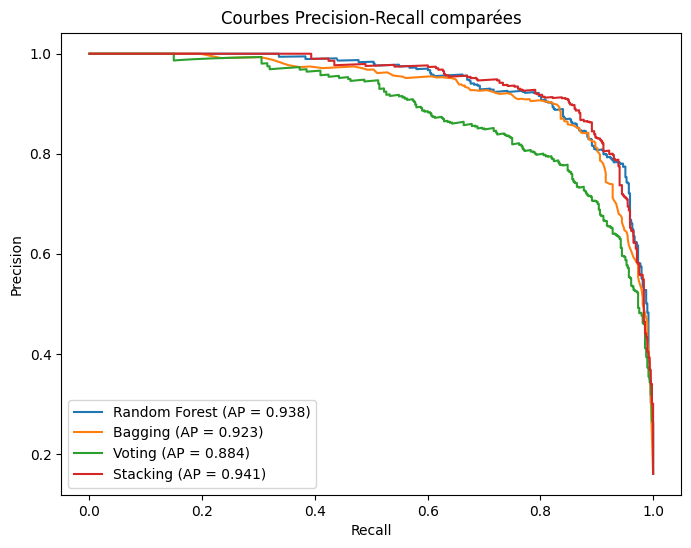

In [28]:
plt.figure(figsize=(8,6))

for name, y_prob in models_pred_prob.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.title("Courbes Precision-Recall comparées")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

We also plot the Precision-Recall curve, as it allows us to better compare the performance of unbalanced classes.

Here again, we observe that stacking is the best model with high accuracy (94.1%). Once again, the Random Forest model is not far behind the performance of the first (93.8%). The stacking and RF curves are almost superimposed and remain very high. This allows us to say that these are the models that deliver the best performance.

All models remain effective, but stacking is the most effective. Random Forest is almost equivalent, which would provide a simpler alternative.

#### Confusion Matrix

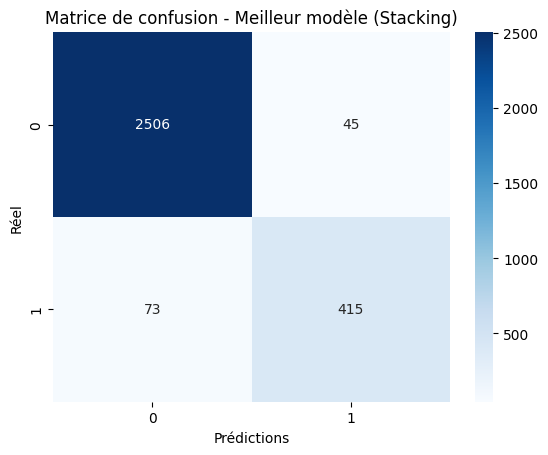

In [29]:
best_model = stacking
y_pred_best = y_pred_stack

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Meilleur modèle (Stacking)")
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.show()

The stacking model has excellent overall performance with a good compromise between accuracy and recall. It makes few errors and misses few true positives. The results of the confusion matrix remain consistent with those of the ROC curve and the Precision-Recall curve.

The Stacking model is robust, accurate, and well calibrated.

### Creation of the new variables :

In [30]:
"""We create a division witch return NaN if the division is not possible."""
def safe_div(x, y):
    return np.where((y == 0) | (y.isna()), np.nan, x / y)

In [31]:
df['Avg_Trans_Value'] = safe_div(df['Total_Trans_Amt'], df['Total_Trans_Ct'])
df['Trans_Per_Month'] = safe_div(df['Total_Trans_Ct'], df['Months_on_book'])
df['Amount_Per_Month'] = safe_div(df['Total_Trans_Amt'], df['Months_on_book'])
df['Credit_Utilization'] = safe_div(df['Total_Revolving_Bal'], df['Avg_Open_To_Buy'] + df['Total_Revolving_Bal'])
df['Revolving_Ratio'] = safe_div(df['Total_Revolving_Bal'], df['Credit_Limit'])
df['Products_Per_Year'] = safe_div(df['Total_Relationship_Count'], df['Months_on_book']/12)
df['Credit_vs_Activity'] = safe_div(df['Total_Trans_Amt'], df['Credit_Limit'])

In [32]:
print(df['Avg_Trans_Value'].head())
print(df['Trans_Per_Month'].head())
print(df['Amount_Per_Month'].head())
print(df['Credit_Utilization'].head())
print(df['Revolving_Ratio'].head())
print(df['Products_Per_Year'].head())
print(df['Credit_vs_Activity'].head())

0    27.238095
1    39.121212
2    94.350000
3    58.550000
4    29.142857
Name: Avg_Trans_Value, dtype: float64
0    1.076923
1    0.750000
2    0.555556
3    0.588235
4    1.333333
Name: Trans_Per_Month, dtype: float64
0    29.333333
1    29.340909
2    52.416667
3    34.441176
4    38.857143
Name: Amount_Per_Month, dtype: float64
0    0.061224
1    0.104651
2    0.000000
3    0.759734
4    0.000000
Name: Credit_Utilization, dtype: float64
0    0.061224
1    0.104651
2    0.000000
3    0.759734
4    0.000000
Name: Revolving_Ratio, dtype: float64
0    1.538462
1    1.636364
2    1.333333
3    1.058824
4    2.857143
Name: Products_Per_Year, dtype: float64
0    0.090143
1    0.156371
2    0.552077
3    0.353456
4    0.173028
Name: Credit_vs_Activity, dtype: float64


In [33]:
print(df.head())

      Attrition_Flag  Customer_Age Gender  Dependent_count Education_Level  \
0  Existing Customer            45      M                3     High School   
1  Existing Customer            49      F                5        Graduate   
2  Existing Customer            51      M                3        Graduate   
3  Existing Customer            40      F                4     High School   
4  Existing Customer            40      M                3      Uneducated   

  Marital_Status Income_Category Card_Category  Months_on_book  \
0        Married     $60K - $80K          Blue              39   
1         Single  Less than $40K          Blue              44   
2        Married    $80K - $120K          Blue              36   
3        Unknown  Less than $40K          Blue              34   
4        Married     $60K - $80K          Blue              21   

   Total_Relationship_Count  ...  Total_Trans_Ct  Total_Ct_Chng_Q4_Q1  \
0                         5  ...              42             

In [34]:
new_df = df.copy()

In [35]:
print(new_df.head())

      Attrition_Flag  Customer_Age Gender  Dependent_count Education_Level  \
0  Existing Customer            45      M                3     High School   
1  Existing Customer            49      F                5        Graduate   
2  Existing Customer            51      M                3        Graduate   
3  Existing Customer            40      F                4     High School   
4  Existing Customer            40      M                3      Uneducated   

  Marital_Status Income_Category Card_Category  Months_on_book  \
0        Married     $60K - $80K          Blue              39   
1         Single  Less than $40K          Blue              44   
2        Married    $80K - $120K          Blue              36   
3        Unknown  Less than $40K          Blue              34   
4        Married     $60K - $80K          Blue              21   

   Total_Relationship_Count  ...  Total_Trans_Ct  Total_Ct_Chng_Q4_Q1  \
0                         5  ...              42             

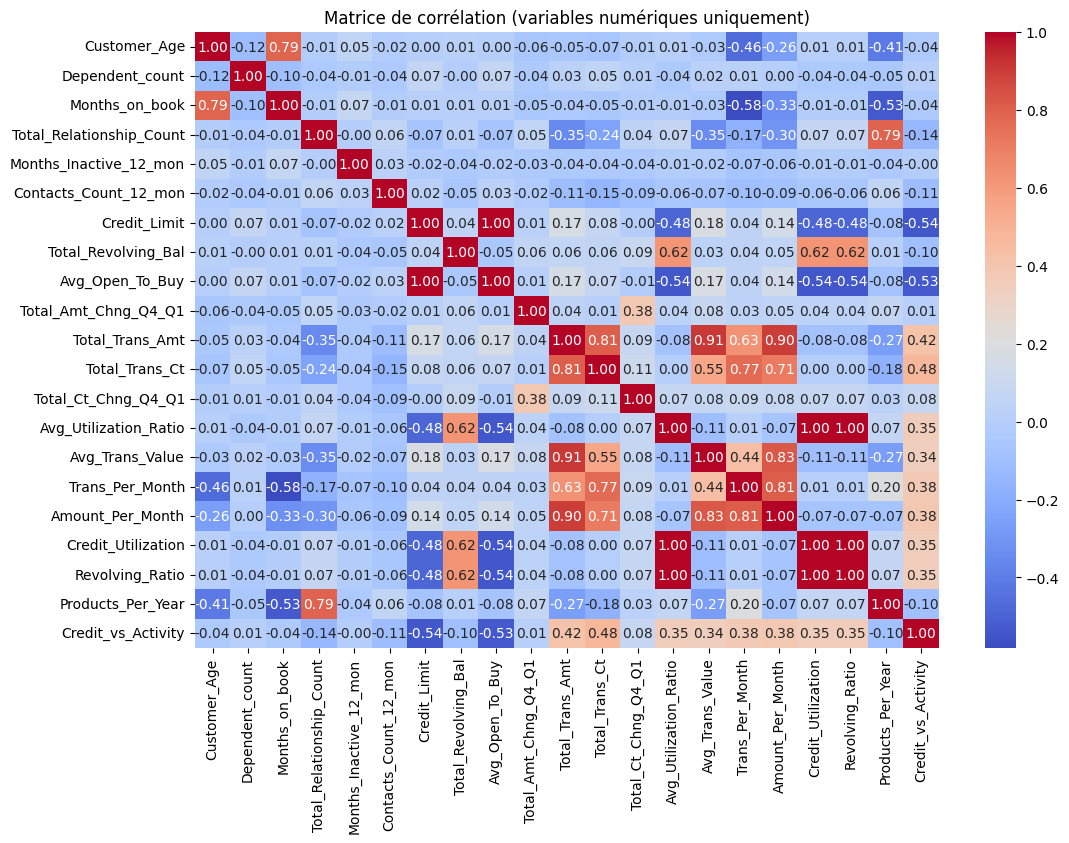

In [36]:
# Sélection des colonnes numériques
numeric_df = new_df.select_dtypes(include=['number'])

# Matrice de corrélation
new_corr_matrix = numeric_df.corr()

# Affichage de la matrice
plt.figure(figsize=(12, 8))
sns.heatmap(new_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation (variables numériques uniquement)")
plt.show()

In [37]:
new_df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Value,Trans_Per_Month,Amount_Per_Month,Credit_Utilization,Revolving_Ratio,Products_Per_Year,Credit_vs_Activity
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,42,1.625,0.061,27.238095,1.076923,29.333333,0.061224,0.061224,1.538462,0.090143
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,33,3.714,0.105,39.121212,0.750000,29.340909,0.104651,0.104651,1.636364,0.156371
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,20,2.333,0.000,94.350000,0.555556,52.416667,0.000000,0.000000,1.333333,0.552077
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,20,2.333,0.760,58.550000,0.588235,34.441176,0.759734,0.759734,1.058824,0.353456
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,28,2.500,0.000,29.142857,1.333333,38.857143,0.000000,0.000000,2.857143,0.173028


In [38]:
new_df.isna().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


In [39]:
print("Observations with 'Uknown': {} sur {}".format((new_df[(new_df["Education_Level"] == "Unknown") |
   (new_df["Marital_Status"] == "Unknown") |
   (new_df["Income_Category"] == "Unknown")].shape[0]), new_df.shape[0]))

Observations with 'Uknown': 3046 sur 10127


We do the same operations that we already did higher. <br>

In [40]:
# Variables à encoder
ordinal_cols = ["Education_Level", "Income_Category", "Card_Category"]
onehot_cols = ["Gender", "Marital_Status"]

# Définition des ordres logiques pour les variables ordinales
education_order = ["Unknown", "Uneducated", "High School", "College", "Graduate", "Post-Graduate", "Doctorate"]
income_order = ["Unknown", "Less than $40K", "$40K - $60K", "$60K - $80K", "$80K - $120K", "$120K +"]
card_order = ["Blue", "Silver", "Gold", "Platinum"]

# Création d'une copie pour ne pas modifier df
new_df_enc = new_df.copy()

# Encodage ordinal (les catégories sont converties en valeurs entières selon l'ordre défini)
ord_encoder = OrdinalEncoder(categories=[education_order, income_order, card_order])
new_df_enc[ordinal_cols] = ord_encoder.fit_transform(new_df_enc[ordinal_cols])

# Encodage one-hot (les catégories deviennent des colonnes binaires)
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
onehot_encoded = pd.DataFrame(onehot_encoder.fit_transform(new_df_enc[onehot_cols]), columns=onehot_encoder.get_feature_names_out(onehot_cols), index=new_df_enc.index)


new_df_enc = pd.concat([new_df_enc.drop(columns=onehot_cols), onehot_encoded], axis=1)
new_df_enc.head()

,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,...,Credit_Utilization,Revolving_Ratio,Products_Per_Year,Credit_vs_Activity,Gender_F,Gender_M,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown
0,Existing Customer,45,3,2.0,3.0,0.0,39,5,1,3,...,0.061224,0.061224,1.538462,0.090143,0.0,1.0,0.0,1.0,0.0,0.0
1,Existing Customer,49,5,4.0,1.0,0.0,44,6,1,2,...,0.104651,0.104651,1.636364,0.156371,1.0,0.0,0.0,0.0,1.0,0.0
2,Existing Customer,51,3,4.0,4.0,0.0,36,4,1,0,...,0.000000,0.000000,1.333333,0.552077,0.0,1.0,0.0,1.0,0.0,0.0
3,Existing Customer,40,4,2.0,1.0,0.0,34,3,4,1,...,0.759734,0.759734,1.058824,0.353456,1.0,0.0,0.0,0.0,0.0,1.0
4,Existing Customer,40,3,1.0,3.0,0.0,21,5,1,0,...,0.000000,0.000000,2.857143,0.173028,0.0,1.0,0.0,1.0,0.0,0.0


We recreate the target variable and standardize the data. <br>
We have to do the same manipulations than we already did to have the same database and recreate the differents models to compare them before and after the new variables.

### 1 - New Logistic Regression

In [41]:
X1 = new_df_enc.drop(columns=['Attrition_Flag'])
y1 = new_df_enc['Attrition_Flag']

scaler1 = StandardScaler()
X_scaled1 = scaler1.fit_transform(X1)

In [42]:
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(X_scaled1, y1, test_size=0.3, random_state=42, stratify=y1)

new_model = LogisticRegression(max_iter=1000)
new_model.fit(new_X_train, new_y_train)

new_y_pred = new_model.predict(new_X_test)

print(confusion_matrix(new_y_test, new_y_pred))
print(classification_report(new_y_test, new_y_pred))

[[ 303  185]
 [  84 2467]]
                   precision    recall  f1-score   support

Attrited Customer       0.78      0.62      0.69       488
Existing Customer       0.93      0.97      0.95      2551

         accuracy                           0.91      3039
        macro avg       0.86      0.79      0.82      3039
     weighted avg       0.91      0.91      0.91      3039



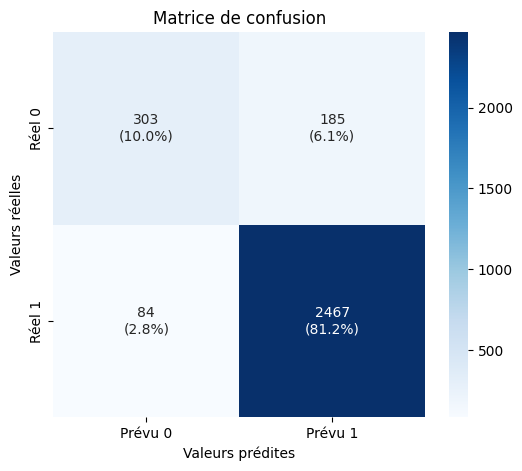

In [43]:
new_cm = confusion_matrix(new_y_test, new_y_pred)
new_cm_sum = np.sum(new_cm)
new_cm_perc = new_cm / new_cm_sum * 100

annot = np.empty_like(new_cm).astype(str)

for i in range(new_cm.shape[0]):
    for j in range(new_cm.shape[1]):
        annot[i, j] = f"{new_cm[i, j]}\n({new_cm_perc[i, j]:.1f}%)"

plt.figure(figsize=(6, 5))
sns.heatmap(new_cm, annot=annot, fmt='', cmap='Blues', xticklabels=['Prévu 0', 'Prévu 1'], yticklabels=['Réel 0', 'Réel 1'])
plt.title('Matrice de confusion')
plt.xlabel('Valeurs prédites')
plt.ylabel('Valeurs réelles')
plt.show()

After the new variables, we have the same results with the ligistic regression. <br> So there is no impact with adding more variables to strengthen the model. <br>
Let's try now with the others models.

### 2 - New Random Forest

In [44]:
new_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2,3,4,5],
}

new_grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), new_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
new_grid_rf.fit(new_X_train, new_y_train)

print(new_grid_rf.best_params_)

{'max_depth': 15, 'min_samples_split': 3, 'n_estimators': 200}


In [45]:
new_best_rf = RandomForestClassifier(max_depth=None, min_samples_split=5, n_estimators=150, random_state=42)
new_best_rf.fit(new_X_train, new_y_train)
new_y_pred_rf = new_best_rf.predict(new_X_test)

print(f"Accuracy (Random Forest): {round(accuracy_score(new_y_test, new_y_pred_rf)*100,4)}%")
print(classification_report(new_y_test, new_y_pred_rf))

Accuracy (Random Forest): 95.5907%
                   precision    recall  f1-score   support

Attrited Customer       0.92      0.80      0.85       488
Existing Customer       0.96      0.99      0.97      2551

         accuracy                           0.96      3039
        macro avg       0.94      0.89      0.91      3039
     weighted avg       0.95      0.96      0.95      3039



/tmp/ipython-input-2525368804.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=new_importances_rf[new_indices][:15], y=new_features[new_indices][:15], palette='crest')


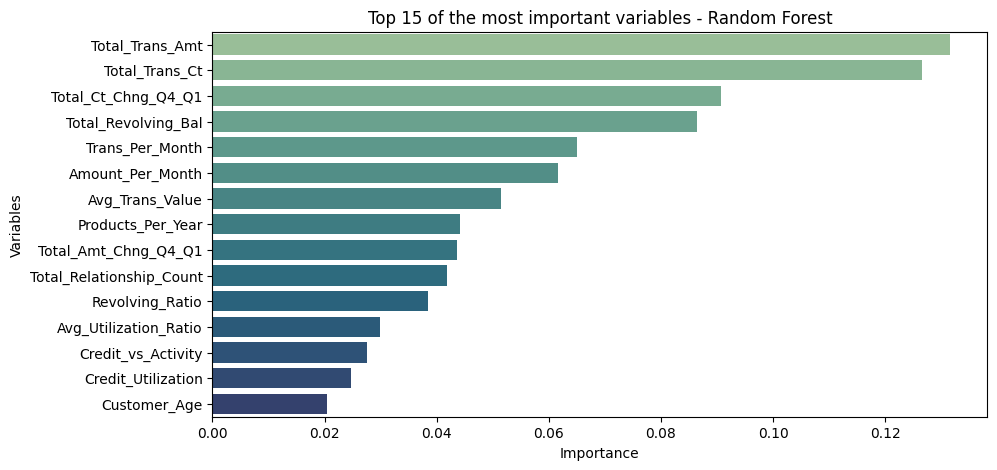

In [46]:
new_importances_rf = new_best_rf.feature_importances_
new_indices = np.argsort(new_importances_rf)[::-1]
new_features = X1.columns

plt.figure(figsize=(10,5))
sns.barplot(x=new_importances_rf[new_indices][:15], y=new_features[new_indices][:15], palette='crest')
plt.title("Top 15 of the most important variables - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

The ranking of the most important variables for the random forest has not changed. <br>
Adding variables to our model decrease the accuracy of ou Random Forest model.

### 3 - New Bagging

In [47]:
new_bagging = BaggingClassifier( estimator=DecisionTreeClassifier(), n_estimators=150, random_state=42)
new_bagging.fit(new_X_train, new_y_train)
new_y_pred_bag = new_bagging.predict(new_X_test)

print(f"Accuracy (Bagging): {round(accuracy_score(new_y_test, new_y_pred_bag) * 100,4)}%")

Accuracy (Bagging): 95.4919%


For the new bagging process, the precision decease either. <br>

### 4 - New Voting

In [48]:
new_log_reg = LogisticRegression(max_iter=1000)
new_svm = SVC(probability=True)
new_rf = new_best_rf

new_voting = VotingClassifier(estimators=[('lr', new_log_reg), ('svm', new_svm), ('rf', new_rf)], voting='soft')

new_voting.fit(new_X_train, new_y_train)
new_y_pred_vote = new_voting.predict(new_X_test)

print(f"Accuracy (Voting):, {round(accuracy_score(new_y_test, new_y_pred_vote)*100,4)}%")

Accuracy (Voting):, 93.9454%


For the voting model, the precision increase at 93,98%. We were at 92,66% wich is an increase of +1.32%.

### 5 - New Stacking

In [49]:
new_stacking = StackingClassifier( estimators=[ ('rf', new_rf), ('svm', new_svm)], final_estimator=LogisticRegression(), passthrough=True)
new_stacking.fit(new_X_train, new_y_train)
new_y_pred_stack = new_stacking.predict(new_X_test)

print(f"Accuracy (Stacking):, {round(accuracy_score(new_y_test, new_y_pred_stack)*100,4)}%")

Accuracy (Stacking):, 96.0842%


The stacking model decrease the accuracy model such as the others models.

Now, let's compare the models and try others classifications models.

In [50]:
models = {
    "Random Forest": new_y_pred_rf,
    "Bagging": new_y_pred_bag,
    "Voting": new_y_pred_vote,
    "Stacking": new_y_pred_stack
}

for name, new_preds in models.items():
    print(f"\n===== {name} =====")
    print(f"Accuracy:  {round(accuracy_score(new_y_test, new_preds)*100, 4)}%")
    print(f"Precision: {round(precision_score(new_y_test, new_preds, average='weighted'), 4)}")
    print(f"Recall:    {round(recall_score(new_y_test, new_preds, average='weighted'), 4)}")
    print(f"F1-score:  {round(f1_score(new_y_test, new_preds, average='weighted'), 4)}")
    print("Confusion matrix:")
    print(confusion_matrix(new_y_test, new_preds))


===== Random Forest =====
Accuracy:  95.5907%
Precision: 0.955
Recall:    0.9559
F1-score:  0.9546
Confusion matrix:
[[ 389   99]
 [  35 2516]]

===== Bagging =====
Accuracy:  95.4919%
Precision: 0.9542
Recall:    0.9549
F1-score:  0.9544
Confusion matrix:
[[ 407   81]
 [  56 2495]]

===== Voting =====
Accuracy:  93.9454%
Precision: 0.9374
Recall:    0.9395
F1-score:  0.9372
Confusion matrix:
[[ 355  133]
 [  51 2500]]

===== Stacking =====
Accuracy:  96.0842%
Precision: 0.9601
Recall:    0.9608
F1-score:  0.9601
Confusion matrix:
[[ 407   81]
 [  38 2513]]


/tmp/ipython-input-2105323192.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=new_models, y=new_scores, palette='viridis')


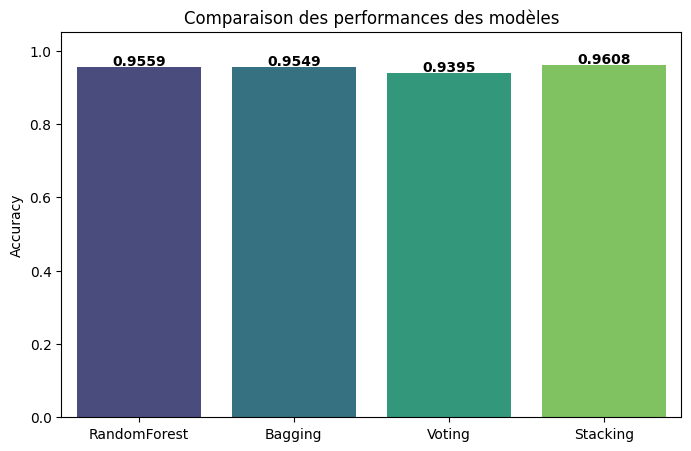

In [51]:
new_models = ['RandomForest', 'Bagging', 'Voting', 'Stacking']
new_scores = [
    accuracy_score(new_y_test, new_y_pred_rf),
    accuracy_score(new_y_test, new_y_pred_bag),
    accuracy_score(new_y_test, new_y_pred_vote),
    accuracy_score(new_y_test, new_y_pred_stack)
]

plt.figure(figsize=(8,5))
ax = sns.barplot(x=new_models, y=new_scores, palette='viridis')

plt.title("Comparaison des performances des modèles")
plt.ylabel("Accuracy")

for i, v in enumerate(new_scores):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.ylim(0, 1.05)
plt.show()

After adding new variables, there is just the voting model who increase the accuracy wich mean the others models are better without the new variables.

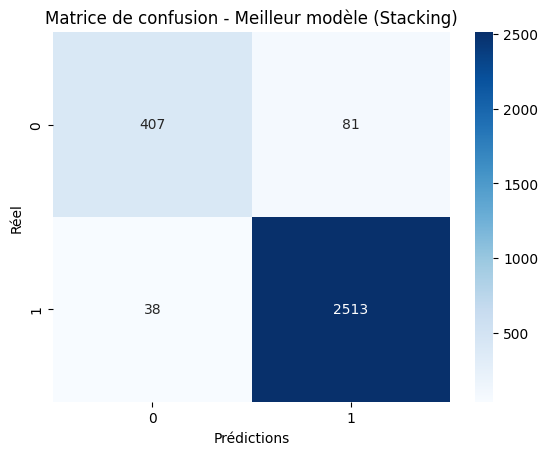

In [52]:
new_best_model = stacking
new_y_pred_best = new_y_pred_stack

new_cm = confusion_matrix(new_y_test, new_y_pred_best)
sns.heatmap(new_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Meilleur modèle (Stacking)")
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.show()

We now going to search a better precision with differents models like XGBOOST to start and then test with CATBOOST because through our research, we found that these are effective models for banking classification.

### 6 - Implementation of XGBOOST with the first database.

In [53]:
gboost = GradientBoostingClassifier(random_state=42)
gboost.fit(X_train, y_train)

y_pred_gb = gboost.predict(X_test)

print("=== Gradient Boosting - Baseline ===")
print(f"Accuracy (GBoost): {round(accuracy_score(y_test, y_pred_gb)*100, 4)}%")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting - Baseline ===
Accuracy (GBoost): 95.9197%
[[2521   30]
 [  94  394]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2551
           1       0.93      0.81      0.86       488

    accuracy                           0.96      3039
   macro avg       0.95      0.90      0.92      3039
weighted avg       0.96      0.96      0.96      3039



We have an accuracy of 95,92% wich is not better than the stacking model but it's among the best scores. Let's test now with

In [54]:
param_grid_gb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train, y_train)

print("Meilleurs hyperparamètres GBoost :")
print(grid_gb.best_params_)

Meilleurs hyperparamètres GBoost :
{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 1.0}


#### XGBOOST on the new variables.

In [55]:
best_gb_new = GradientBoostingClassifier(
    n_estimators=grid_gb.best_params_['n_estimators'],
    learning_rate=grid_gb.best_params_['learning_rate'],
    max_depth=grid_gb.best_params_['max_depth'],
    subsample=grid_gb.best_params_['subsample'],
    min_samples_split=grid_gb.best_params_['min_samples_split'],
    min_samples_leaf=grid_gb.best_params_['min_samples_leaf'],
    random_state=42
)

best_gb_new.fit(new_X_train, new_y_train)
new_y_pred_gb = best_gb_new.predict(new_X_test)

print("=== Best GBoost avec nouvelles variables ===")
print(f"Accuracy (Best GBoost new features): {round(accuracy_score(new_y_test, new_y_pred_gb)*100, 4)}%")
print(confusion_matrix(new_y_test, new_y_pred_gb))
print(classification_report(new_y_test, new_y_pred_gb))

=== Best GBoost avec nouvelles variables ===
Accuracy (Best GBoost new features): 96.874%
[[ 420   68]
 [  27 2524]]
                   precision    recall  f1-score   support

Attrited Customer       0.94      0.86      0.90       488
Existing Customer       0.97      0.99      0.98      2551

         accuracy                           0.97      3039
        macro avg       0.96      0.93      0.94      3039
     weighted avg       0.97      0.97      0.97      3039



The accuracy after the new variables is boosted by the model and we now have a 96,87% of accuracy when the best performance of the stacking was 96,12% before and after adding variables.

/tmp/ipython-input-3545123340.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=scores, palette='viridis')


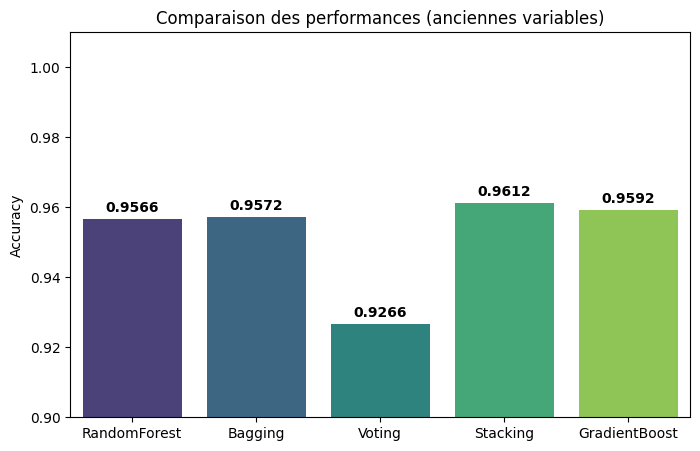

In [56]:
models = ['RandomForest', 'Bagging', 'Voting', 'Stacking', 'GradientBoost']
scores = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_bag),
    accuracy_score(y_test, y_pred_vote),
    accuracy_score(y_test, y_pred_stack),
    accuracy_score(y_test, y_pred_gb)
]

plt.figure(figsize=(8,5))
ax = sns.barplot(x=models, y=scores, palette='viridis')

plt.title("Comparaison des performances (anciennes variables)")
plt.ylabel("Accuracy")

for i, v in enumerate(scores):
    ax.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

plt.ylim(0.9, 1.01)
plt.show()


We can compare the accuracy of each model before adding new variables. Without the new variables, the GradientBoost was the second best classification model.

/tmp/ipython-input-1489492340.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=new_models, y=new_scores, palette='viridis')


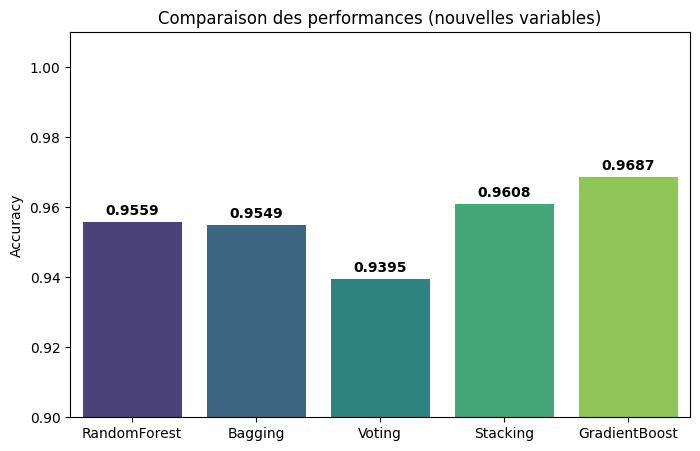

In [57]:
new_models = ['RandomForest', 'Bagging', 'Voting', 'Stacking', 'GradientBoost']
new_scores = [
    accuracy_score(new_y_test, new_y_pred_rf),
    accuracy_score(new_y_test, new_y_pred_bag),
    accuracy_score(new_y_test, new_y_pred_vote),
    accuracy_score(new_y_test, new_y_pred_stack),
    accuracy_score(new_y_test, new_y_pred_gb)
]

plt.figure(figsize=(8,5))
ax = sns.barplot(x=new_models, y=new_scores, palette='viridis')

plt.title("Comparaison des performances (nouvelles variables)")
plt.ylabel("Accuracy")

for i, v in enumerate(new_scores):
    ax.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

plt.ylim(0.9, 1.01)
plt.show()


Then we have the precision of these same models after adding the new variables. The GradientBoost now pass at the first place and pass in the first position with 96,87% of accuracy.

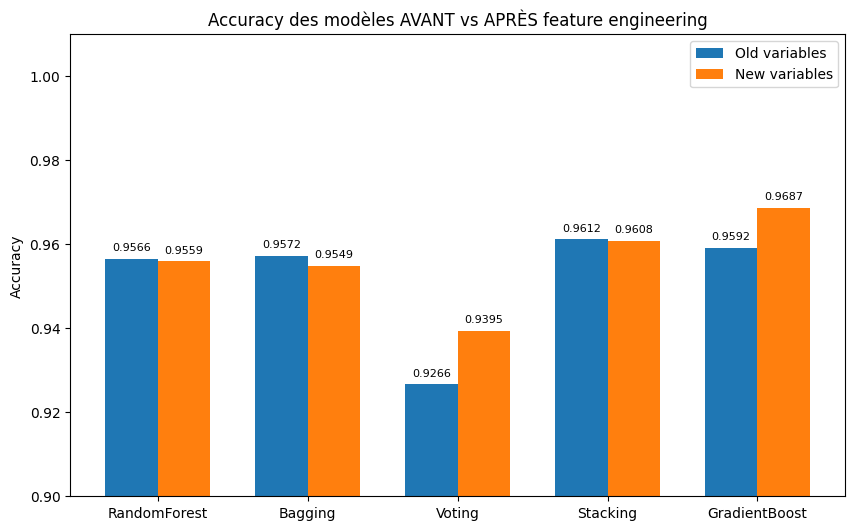

In [58]:
models_all = ['RandomForest', 'Bagging', 'Voting', 'Stacking', 'GradientBoost']

scores_old = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_bag),
    accuracy_score(y_test, y_pred_vote),
    accuracy_score(y_test, y_pred_stack),
    accuracy_score(y_test, y_pred_gb)
]

scores_new = [
    accuracy_score(new_y_test, new_y_pred_rf),
    accuracy_score(new_y_test, new_y_pred_bag),
    accuracy_score(new_y_test, new_y_pred_vote),
    accuracy_score(new_y_test, new_y_pred_stack),
    accuracy_score(new_y_test, new_y_pred_gb)
]

x = np.arange(len(models_all))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, scores_old, width, label='Old variables')
plt.bar(x + width/2, scores_new, width, label='New variables')

plt.xticks(x, models_all)
plt.ylabel("Accuracy")
plt.title("Accuracy des modèles AVANT vs APRÈS feature engineering")
plt.ylim(0.9, 1.01)
plt.legend()

for i, v in enumerate(scores_old):
    plt.text(x[i] - width/2, v + 0.002, f"{v:.4f}", ha='center', fontsize=8)
for i, v in enumerate(scores_new):
    plt.text(x[i] + width/2, v + 0.002, f"{v:.4f}", ha='center', fontsize=8)

plt.show()


If we make a quick comparison between all models, we clearly see that only the voting and the gradientboost model have a positive evolve. The others models lose accuracy with new variables.

Let's try now the Catboost model

### Catboost implementation

In [59]:
cat_baseline = CatBoostClassifier( loss_function='Logloss', eval_metric='Accuracy', iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
cat_baseline.fit(X_train, y_train)
y_pred_cat = cat_baseline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_cat)*100:.4f}%")
print(classification_report(y_test, y_pred_cat))

Accuracy: 97.2030%
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2551
           1       0.94      0.88      0.91       488

    accuracy                           0.97      3039
   macro avg       0.96      0.93      0.95      3039
weighted avg       0.97      0.97      0.97      3039



With the catboost model, we have the best accuracy and recall among all the models. Without adding others variables, we have 97,2% of accuracy on our catboost model.

/tmp/ipython-input-4258207911.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=new_models, y=new_scores, palette='viridis')


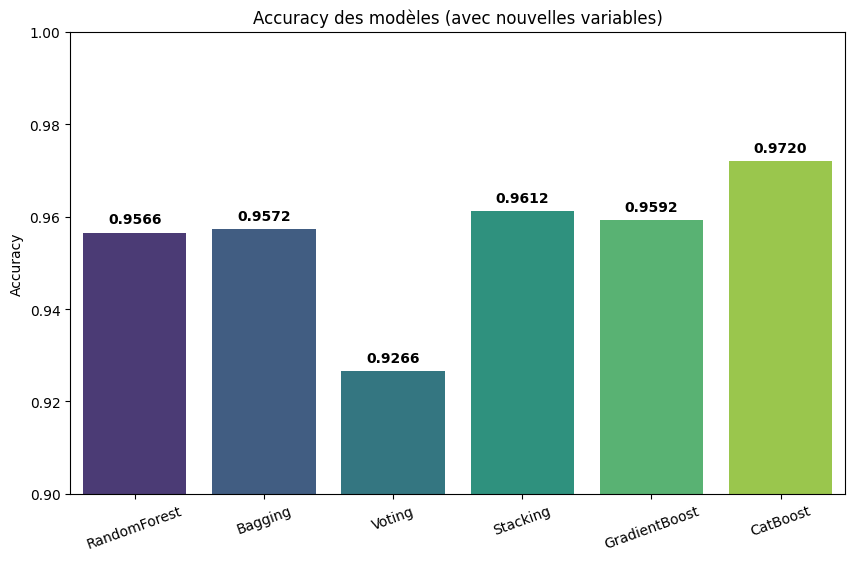

In [60]:
new_models = ['RandomForest', 'Bagging', 'Voting', 'Stacking', 'GradientBoost', 'CatBoost']

new_scores = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_bag),
    accuracy_score(y_test, y_pred_vote),
    accuracy_score(y_test, y_pred_stack),
    accuracy_score(y_test, y_pred_gb),
    accuracy_score(y_test, y_pred_cat)
]

x = np.arange(len(new_models))

plt.figure(figsize=(10,6))
ax = sns.barplot(x=new_models, y=new_scores, palette='viridis')

plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Accuracy of models (with old variables)")

for i, v in enumerate(new_scores):
    ax.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

plt.ylim(0.90, 1)
plt.show()

As we can see, the catboost model is the best model among all the models we have implemented and this without adding new variables.

In [61]:
cat_baseline = CatBoostClassifier( loss_function='Logloss', eval_metric='Accuracy', iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
cat_baseline.fit(new_X_train, new_y_train)
new_y_pred_cat = cat_baseline.predict(new_X_test)

print(f"Accuracy: {accuracy_score(new_y_test, new_y_pred_cat)*100:.4f}%")
print(classification_report(new_y_test, new_y_pred_cat))

Accuracy: 96.9069%
                   precision    recall  f1-score   support

Attrited Customer       0.93      0.87      0.90       488
Existing Customer       0.98      0.99      0.98      2551

         accuracy                           0.97      3039
        macro avg       0.95      0.93      0.94      3039
     weighted avg       0.97      0.97      0.97      3039



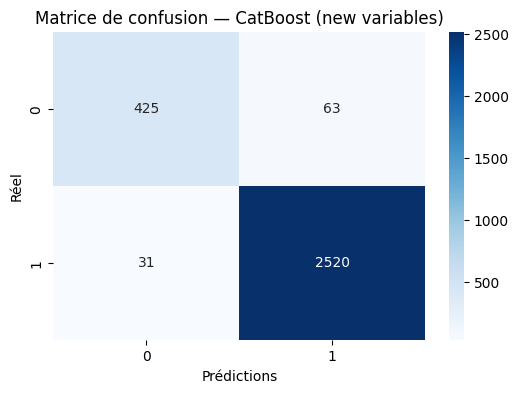

In [62]:
cm_cat = confusion_matrix(new_y_test, new_y_pred_cat)

plt.figure(figsize=(6,4))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion — CatBoost (new variables)")
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.show()

/tmp/ipython-input-2006425154.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=new_models, y=new_scores, palette='viridis')


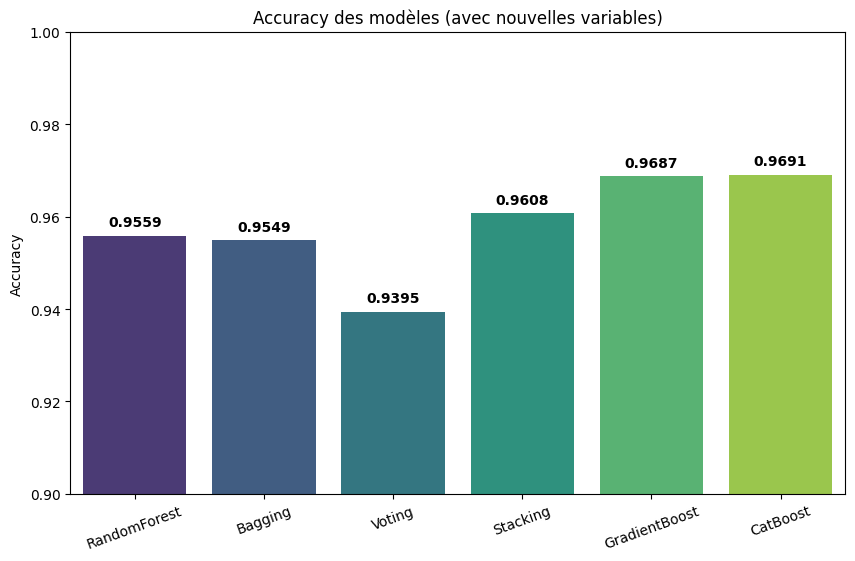

In [63]:
new_models = ['RandomForest', 'Bagging', 'Voting', 'Stacking', 'GradientBoost', 'CatBoost']

new_scores = [
    accuracy_score(new_y_test, new_y_pred_rf),
    accuracy_score(new_y_test, new_y_pred_bag),
    accuracy_score(new_y_test, new_y_pred_vote),
    accuracy_score(new_y_test, new_y_pred_stack),
    accuracy_score(new_y_test, new_y_pred_gb),
    accuracy_score(new_y_test, new_y_pred_cat)
]

x = np.arange(len(new_models))

plt.figure(figsize=(10,6))
ax = sns.barplot(x=new_models, y=new_scores, palette='viridis')

plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Accuracy of models (with new variables)")

for i, v in enumerate(new_scores):
    ax.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

plt.ylim(0.90, 1)
plt.show()

After introducing the engineered variables into the CatBoost model, we observe a slight decrease in performance, which is consistent with other models. However, CatBoost still remains superior to GradientBoost, with a +0.04% improvement after feature engineering and a +0.33% difference when comparing the best-performing versions of both models. <br> <br>
The stacking is less accurate than the Catboost and have a difference of accuracy of -1.08% between the best performance of the two models.

In conclusion, CatBoost emerges as the most effective model for churn prediction, achieving 97.2% accuracy without requiring additional feature engineering. GradientBoost also performs strongly (96.81%), but remains slightly below CatBoost in both performance and robustness.

Given its speed, ability to natively handle categorical variables, and strong predictive capacity, CatBoost represents a reliable and scalable solution that can be deployed by the bank to anticipate contract termination and implement proactive retention strategies for at-risk customers.

<br>

Although overall accuracy is high, it is more important to maximize recall for the churn class (positive), because an error on a churn costs more than a false positive.

<br>
The selected model can detect 97,2% of customers who are likely to leave. The bank can use this information to implement targeted strategies such as:

- Personalized commercial proposals
- Proactive telephone contact
- Discount offers
- Customer relationship optimization
